# AI Usage Disclosure

An AI assistant (Claude) was used as a **code-writing helper** — boilerplate, docstrings, and
debugging. The research design, data, evaluation set, and conclusions are the author's own. All
code was reviewed, executed, and is fully understood by the author. Full note: `AI_USAGE.md`.


# הנגשת זכויות חברתיות באמצעות NLP
## Hebrew Semantic Retrieval for Social-Rights Questions

**Track 3 — Data-Driven NLP** · HIT · Dr. Igor Kleiner  
**Author:** Yanik Gotie (318553526)

**Research question:** Does sentence-embedding *semantic* retrieval (AlephBERT) beat classic
*lexical* retrieval (TF-IDF / BM25) for Hebrew social-rights questions — and does a **hybrid**
of the two beat both? The core difficulty is the gap between citizens' everyday phrasing
("מה מגיע לי אחרי לידה?") and the formal language of official sources.

This notebook runs the whole pipeline: **scrape → corpus → retrievers → evaluation → error analysis → figures**.
It reuses the modules in `src/` so the notebook and the CLI (`python src/run_all.py`) stay in sync.


## 0 · Setup

On **Google Colab**, run the cell below. It installs dependencies and makes the project's
`src/` package importable. Two ways to get the code into Colab — pick one:

* **A. GitHub:** set `REPO_URL` to your repo and run the clone cell.
* **B. Google Drive:** upload the project folder to Drive, mount it, and set `PROJECT_DIR`.

Running **locally** instead? Just set `PROJECT_DIR` to the repo root and skip the install/clone.


In [1]:
import os, sys, subprocess

IN_COLAB = 'google.colab' in sys.modules

# ---- Option A: clone from GitHub -------------------------------------------
REPO_URL = 'https://github.com/YanikGotie/hebrew-rights-retrieval.git'
# If the repo is PRIVATE, create a GitHub token (Settings > Developer settings >
# Personal access tokens, 'repo' scope) and paste it below. Leave '' if the repo
# is PUBLIC (recommended for a course project -> no token needed).
GITHUB_TOKEN = ''

# ---- Option B: a folder already on disk / Google Drive --------------------
PROJECT_DIR = os.getcwd()   # default: assume we are already in the repo root

if IN_COLAB and REPO_URL:
    url = REPO_URL
    if GITHUB_TOKEN:
        url = REPO_URL.replace('https://', f'https://{GITHUB_TOKEN}@')
    PROJECT_DIR = '/content/project'
    if not os.path.isdir(os.path.join(PROJECT_DIR, '.git')):
        subprocess.run(['rm', '-rf', PROJECT_DIR])
        r = subprocess.run(['git', 'clone', '-q', url, PROJECT_DIR])
        if r.returncode != 0:
            raise RuntimeError(
                'git clone failed. If the repo is PRIVATE, set GITHUB_TOKEN above, '
                'or make it PUBLIC on GitHub: Settings > General > Danger Zone > '
                'Change visibility > Public. (Option B: upload the folder to Google '
                'Drive, mount it, and set PROJECT_DIR.)'
            )

os.chdir(PROJECT_DIR)
sys.path.insert(0, os.path.join(PROJECT_DIR, 'src'))
sys.path.insert(0, PROJECT_DIR)
print('PROJECT_DIR =', PROJECT_DIR)


PROJECT_DIR = /content/project


In [2]:
# Dependencies (Colab). python-bidi gives correct right-to-left Hebrew in figures.
if IN_COLAB:
    !pip install -q sentence-transformers rank-bm25 python-bidi >/dev/null
print('dependencies ready')


dependencies ready


## 1 · Data collection & corpus

Sources (public, see `DATA.md` / `ETHICS.md`):

* **Kol-Zchut** (`כל-זכות`) — fetched via the official **MediaWiki API** (clean plain-text
  extracts, CC-BY-SA), across six life-domains: disability, unemployment, health, family,
  income-support, parenting.
* **Bituach Leumi** (`המוסד לביטוח לאומי`) — a small curated set of benefit pages scraped
  from the `#mainContent` region (robots-aware, rate-limited).

Pages are cleaned (niqqud stripped, boilerplate removed) and **chunked** into passages.
The cell below uses the cached raw pulls if present, otherwise it scrapes live.


In [3]:
import build_corpus, config
import pandas as pd, collections

if not os.path.exists(config.CORPUS_PATH):
    build_corpus.build()          # scrape + chunk (uses data/raw cache when available)
corpus = build_corpus.load_corpus()

n_docs = len({r['doc_id'] for r in corpus})
by_dom = collections.Counter(r['domain'] for r in corpus)
by_src = collections.Counter(r['source'] for r in corpus)
print(f'{len(corpus)} chunks from {n_docs} documents')
print('by source :', dict(by_src))
print('by domain :', dict(by_dom))
pd.DataFrame(corpus[:3])[['doc_id','title','domain','text']]


1602 chunks from 296 documents
by source : {'kolzchut': 1584, 'btl': 18}
by domain : {'disability': 368, 'unemployment': 418, 'health': 174, 'family': 222, 'welfare': 206, 'parenting': 210, 'elderly': 4}


,doc_id,title,domain,text
0,kolzchut_5474,"ארגון נכי צה""ל",disability,"יעדי הארגון\nשיפור התנאים הרפואיים, הכלכליים, ..."
1,kolzchut_5474,"ארגון נכי צה""ל",disability,פעילות הארגון\nהארגון הקים ומפעיל חמישה מרכזי ...
2,kolzchut_10422,בדיקת תלות לגמלת ילד נכה,disability,בקצרה\nבדיקת תלות היא בדיקה פיזית שנערכת במסגר...


## 2 · Evaluation set

A hand-authored set of **40 colloquial Hebrew questions**, each mapped to its ground-truth
document(s). Each query carries a `phrasing_gap` tag (how far the wording is from the
source's formal language) used later in the error analysis. A retrieval is a *hit* when a
returned chunk's parent `doc_id` is in the gold set.


In [4]:
import evaluate
queries = evaluate.load_eval()
print(f'{len(queries)} queries')
pd.DataFrame(queries)[['id','domain','phrasing_gap','query','relevant_doc_ids']].head(8)


40 queries


,id,domain,phrasing_gap,query,relevant_doc_ids
0,q01,unemployment,high,"פיטרו אותי מהעבודה, מה מגיע לי?","[kolzchut_2926, kolzchut_1521, btl_btl_3]"
1,q02,unemployment,low,איך מגישים בקשה לדמי אבטלה?,[kolzchut_7558]
2,q03,unemployment,high,"התפטרתי כי עברתי דירה רחוק, אקבל דמי אבטלה?",[kolzchut_13342]
3,q04,unemployment,medium,"אני עצמאי וסגרתי את העסק, מגיע לי אבטלה?",[kolzchut_17837]
4,q05,unemployment,medium,כמה חודשים צריך לעבוד כדי לקבל דמי אבטלה?,"[kolzchut_2926, kolzchut_2921]"
5,q06,unemployment,high,"הוציאו אותי לחופשה בלי משכורת, יש לי זכויות?",[kolzchut_12413]
6,q07,unemployment,high,חייבים להגיע ללשכת התעסוקה כל הזמן?,[kolzchut_1826]
7,q08,unemployment,high,"הציעו לי עבודה שלא מתאימה לי, מותר לי לסרב?",[kolzchut_1901]


## 3 · Retrievers

Five retrievers over a shared interface (`src/retrievers.py`):

1. **TF-IDF** — sparse lexical baseline (Hebrew-aware tokens + stopwords, cosine).
2. **BM25** — Okapi BM25 lexical baseline (bonus comparison).
3. **AlephBERT (semantic)** — Hebrew sentence embeddings, cosine over dense vectors.
4. **Hybrid (RRF)** — Reciprocal Rank Fusion of TF-IDF + semantic.
5. **Hybrid (weighted)** — min-max score fusion of TF-IDF + semantic.

The semantic model `imvladikon/sentence-transformers-alephbert` is downloaded from
HuggingFace on first use and the passage embeddings are cached to `data/processed/`.


In [5]:
import retrievers as R
retrievers = R.build_all(corpus, include_bm25=True)   # downloads AlephBERT on first run
print('retrievers:', list(retrievers))


[semantic] loading imvladikon/sentence-transformers-alephbert on cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.97k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[semantic] encoding 1602 passages...


Batches:   0%|          | 0/51 [00:00<?, ?it/s]

retrievers: ['tfidf', 'semantic', 'bm25', 'hybrid_rrf', 'hybrid_weighted']


## 4 · Qualitative demo

Ask a free-text question and compare what each model returns. This is where the
formal-vs-colloquial gap becomes visible: the lexical models latch onto shared words,
while the semantic model matches meaning.


In [6]:
def show(query, k=3):
    print('Q:', query)
    for name in ['tfidf','semantic','hybrid_rrf']:
        hits = retrievers[name].search(query, k)
        print(f'\n  [{name}]')
        for h in hits:
            print(f"    {h['rank']}. {h['title']}  ({h['doc_id']}, score={h['score']:.3f})")
    print('-'*70)

show('פיטרו אותי מהעבודה, מה מגיע לי?')
show('הילד שלי מתעכב בהתפתחות, לאן פונים?')


Q: פיטרו אותי מהעבודה, מה מגיע לי?

  [tfidf]
    1. זכאות לגמלת הבטחת הכנסה ובעלות על רכב  (kolzchut_2088, score=0.161)
    2. ניכוי הכנסות מדמי אבטלה  (kolzchut_14911, score=0.149)
    3. איסור ניכוי שכר מנער הנעדר מעבודתו לצורך לימודי ערב בבית ספר מקצועי  (kolzchut_6689, score=0.133)

  [semantic]
    1. דמי אבטלה  (kolzchut_1521, score=0.665)
    2. דמי אבטלה בתקופת מלחמת חרבות ברזל (מלחמת התקומה)  (kolzchut_21223, score=0.633)
    3. התפטרות בנסיבות המזכות בדמי אבטלה ללא תקופת המתנה  (kolzchut_13342, score=0.631)

  [hybrid_rrf]
    1. מדריך להורים של ילדים עם מוגבלות  (kolzchut_14977, score=0.029)
    2. התפטרות בנסיבות המזכות בדמי אבטלה ללא תקופת המתנה  (kolzchut_13342, score=0.025)
    3. התפטרות בנסיבות המזכות בדמי אבטלה ללא תקופת המתנה  (kolzchut_13342, score=0.024)
----------------------------------------------------------------------
Q: הילד שלי מתעכב בהתפתחות, לאן פונים?

  [tfidf]
    1. אבחון אוטיזם  (kolzchut_246, score=0.186)
    2. אבחון רפואי התפתחותי לילדים (שירותי 

## 5 · Quantitative evaluation

Metrics: **Recall@k** (k = 1, 3, 5, 10), **MRR**, **nDCG@10**, **MAP** — written to
`results/metrics.csv` and `results/per_query.csv`.


In [7]:
metrics_df, per_query_df = evaluate.run(retrievers)
metrics_df


[eval] tfidf            recall@1=0.475  recall@3=0.725  recall@5=0.825  recall@10=0.85  mrr=0.6182  ndcg@10=0.6485  map=0.5876
[eval] semantic         recall@1=0.475  recall@3=0.7  recall@5=0.725  recall@10=0.775  mrr=0.5786  ndcg@10=0.5971  map=0.5397
[eval] bm25             recall@1=0.5  recall@3=0.65  recall@5=0.825  recall@10=0.875  mrr=0.6119  ndcg@10=0.6473  map=0.5777
[eval] hybrid_rrf       recall@1=0.55  recall@3=0.75  recall@5=0.8  recall@10=0.875  mrr=0.6678  ndcg@10=0.7037  map=0.6524
[eval] hybrid_weighted  recall@1=0.55  recall@3=0.725  recall@5=0.8  recall@10=0.85  mrr=0.6532  ndcg@10=0.6807  map=0.6315

[eval] metrics -> /content/project/results/metrics.csv
[eval] per-query -> /content/project/results/per_query.csv


,recall@1,recall@3,recall@5,recall@10,mrr,ndcg@10,map
retriever,,,,,,,
tfidf,0.475,0.725,0.825,0.850,0.6182,0.6485,0.5876
semantic,0.475,0.700,0.725,0.775,0.5786,0.5971,0.5397
bm25,0.500,0.650,0.825,0.875,0.6119,0.6473,0.5777
hybrid_rrf,0.550,0.750,0.800,0.875,0.6678,0.7037,0.6524
hybrid_weighted,0.550,0.725,0.800,0.850,0.6532,0.6807,0.6315


## 5b · Train / validation / test split

This is retrieval, so the split is **query-level**: the corpus is the index (fit without labels), and the 40 labeled queries are split (stratified by domain, seed 42) into **validation/dev (14)** and **held-out test (26)**. No hyper-parameters are tuned on the labeled queries, so the split is an unbiased robustness check.


In [8]:
import splits, eval_splits
splits.make_split()
split_df = eval_splits.run()
split_df


[split] dev=14 test=26 -> /content/project/data/processed/eval_split.json
           split       retriever  recall@1  recall@3  recall@5  recall@10    mrr  n_queries
dev (validation)           tfidf    0.5714    0.6429    0.7857     0.8571 0.6472         14
dev (validation)        semantic    0.4286    0.7143    0.7143     0.7857 0.5675         14
dev (validation)            bm25    0.5000    0.7143    0.8571     0.8571 0.6238         14
dev (validation)      hybrid_rrf    0.5000    0.6429    0.7857     0.9286 0.6263         14
dev (validation) hybrid_weighted    0.5000    0.7857    0.7857     0.8571 0.6429         14
 test (held-out)           tfidf    0.4231    0.7692    0.8462     0.8462 0.6026         26
 test (held-out)        semantic    0.5000    0.6923    0.7308     0.7692 0.5846         26
 test (held-out)            bm25    0.5000    0.6154    0.8077     0.8846 0.6055         26
 test (held-out)      hybrid_rrf    0.5769    0.8077    0.8077     0.8462 0.6902         26
 test 

,split,retriever,recall@1,recall@3,recall@5,recall@10,mrr,n_queries
0,dev (validation),tfidf,0.5714,0.6429,0.7857,0.8571,0.6472,14
1,dev (validation),semantic,0.4286,0.7143,0.7143,0.7857,0.5675,14
2,dev (validation),bm25,0.5000,0.7143,0.8571,0.8571,0.6238,14
3,dev (validation),hybrid_rrf,0.5000,0.6429,0.7857,0.9286,0.6263,14
4,dev (validation),hybrid_weighted,0.5000,0.7857,0.7857,0.8571,0.6429,14
5,test (held-out),tfidf,0.4231,0.7692,0.8462,0.8462,0.6026,26
6,test (held-out),semantic,0.5000,0.6923,0.7308,0.7692,0.5846,26
7,test (held-out),bm25,0.5000,0.6154,0.8077,0.8846,0.6055,26
8,test (held-out),hybrid_rrf,0.5769,0.8077,0.8077,0.8462,0.6902,26
9,test (held-out),hybrid_weighted,0.5769,0.6923,0.8077,0.8462,0.6587,26


## 6 · Visualizations

Saved to `results/figures/` and shown inline below.


[viz] saved /content/project/results/figures/metrics_bar.png
[viz] saved /content/project/results/figures/recall_curve.png
[viz] saved /content/project/results/figures/winloss_heatmap.png
[viz] saved /content/project/results/figures/embedding_tsne.png


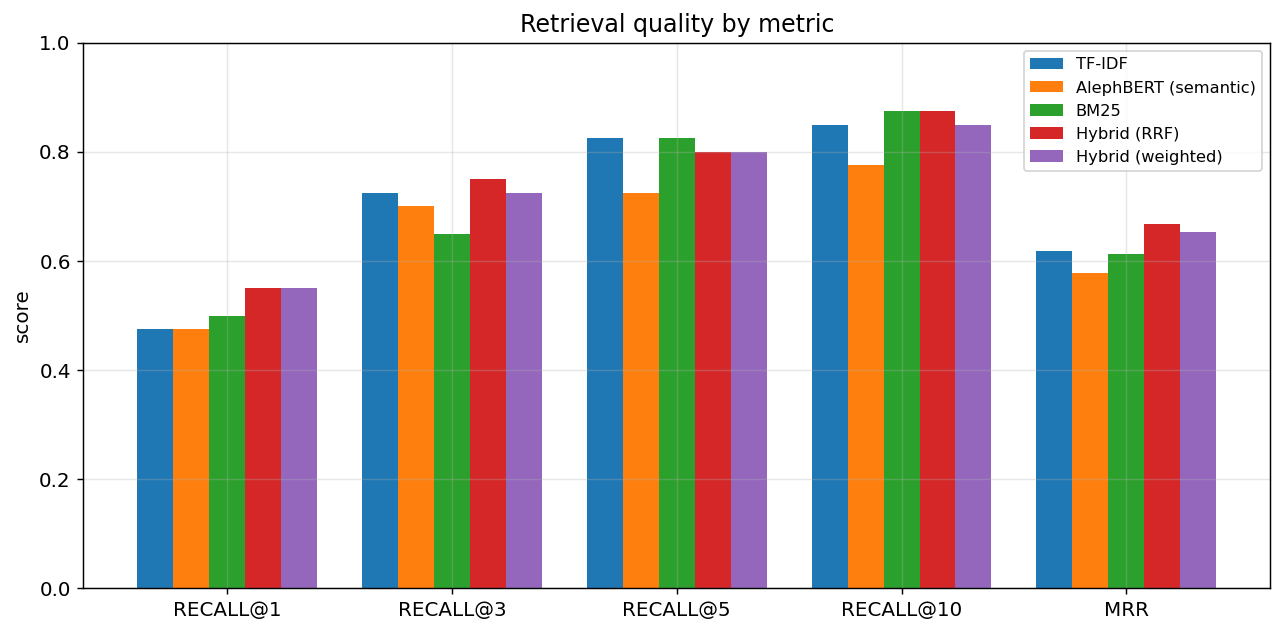

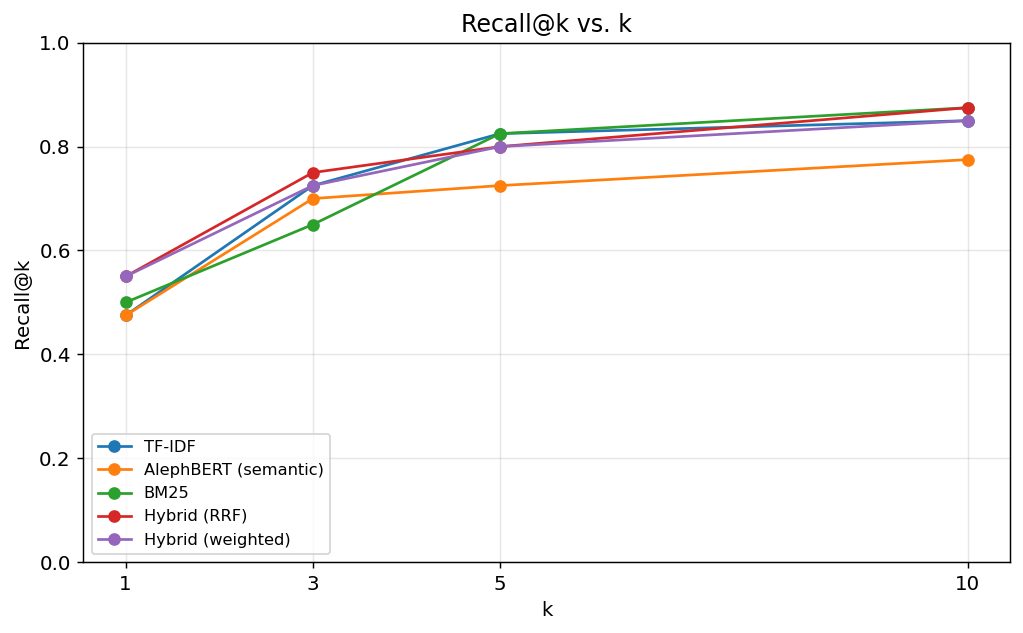

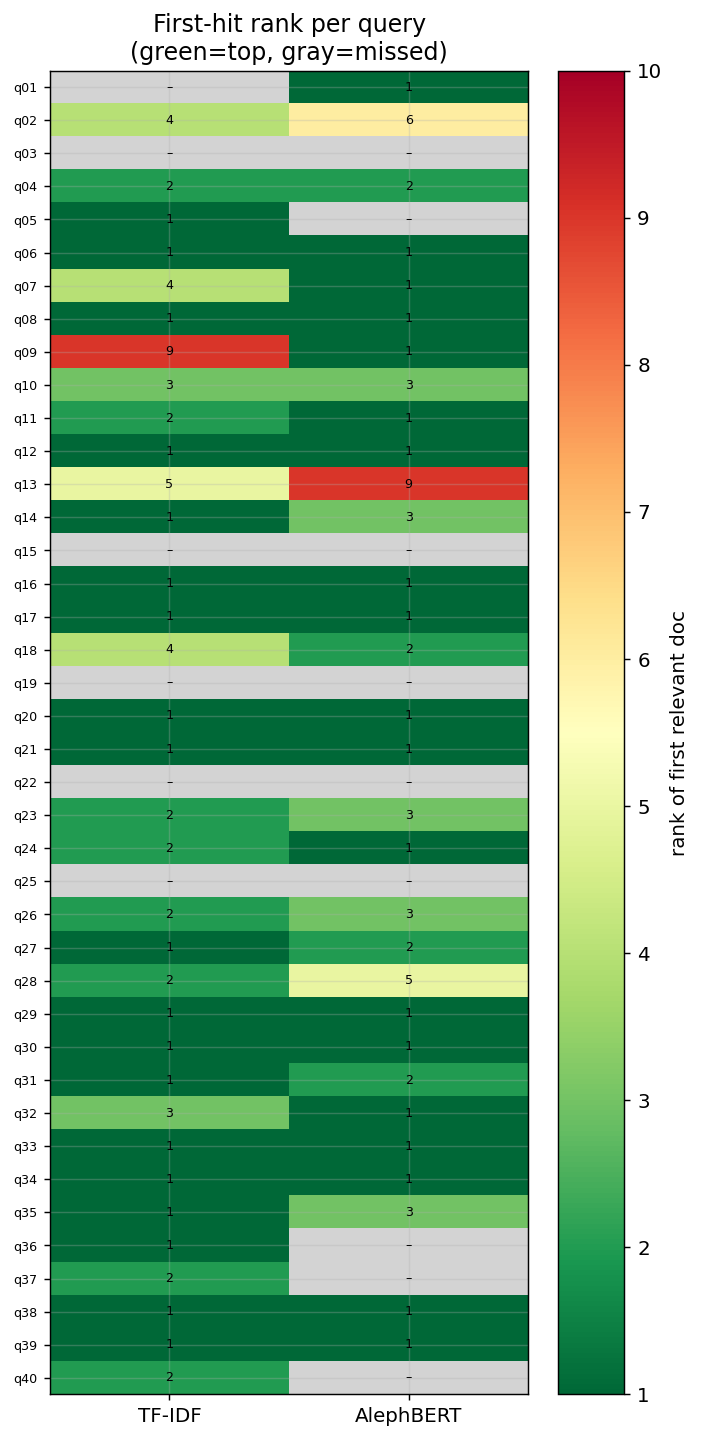

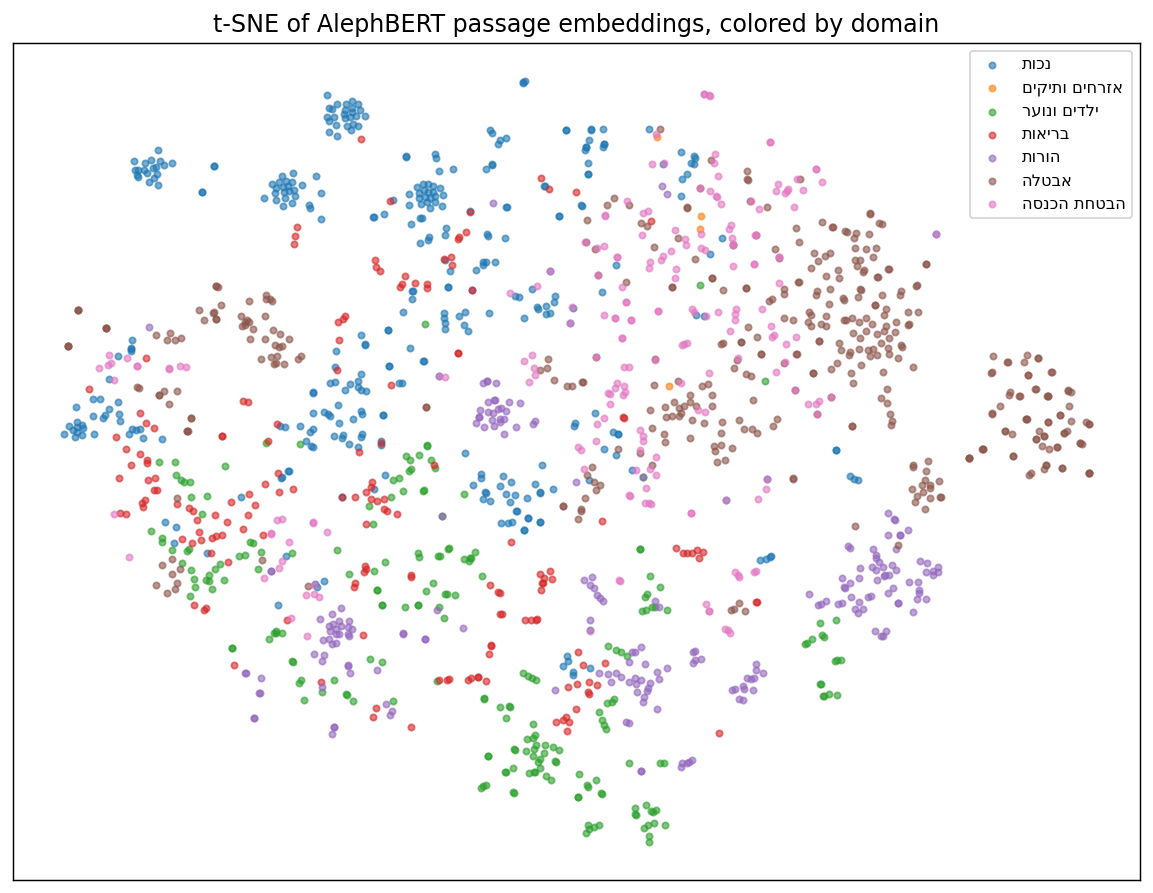

In [9]:
import visualize
emb = getattr(retrievers['semantic'], 'embeddings', None)
visualize.run(metrics_df, per_query_df, corpus, emb)

from IPython.display import Image, display
for fig in ['metrics_bar.png','recall_curve.png','winloss_heatmap.png','embedding_tsne.png']:
    p = os.path.join(config.FIGURES_DIR, fig)
    if os.path.exists(p): display(Image(p))


## 7 · Error analysis

≥10 worked examples grouped into *semantic-wins*, *lexical-wins*, and *both-fail*, each with
an automatic diagnosis. Written to `results/error_analysis.md`.


In [10]:
import error_analysis
error_analysis.build(retrievers, corpus)
from IPython.display import Markdown, display
display(Markdown(open(config.ERROR_ANALYSIS_PATH, encoding='utf-8').read()))


[error-analysis] 16 examples -> /content/project/results/error_analysis.md


# Error Analysis — Lexical (TF-IDF) vs. Semantic (AlephBERT)

Each query is judged at document level (top-3). Rank `None` means the gold document was not retrieved in the top results. The diagnosis combines the manual `phrasing_gap` tag with the literal word overlap between the query and the gold title.


**Summary:** 4 semantic-wins, 5 lexical-wins, 7 both-fail (out of 40 queries).


## A. Semantic wins, lexical fails (synonymy / colloquial → formal)

**1. [q01 · unemployment] “פיטרו אותי מהעבודה, מה מגיע לי?”**  
- Gold: זכאות לדמי אבטלה, דמי אבטלה, דמי אבטלה  
- Lexical top-3: זכאות לגמלת הבטחת הכנסה ובעלות על רכב, ניכוי הכנסות מדמי אבטלה, איסור ניכוי שכר מנער הנעדר מעבודתו לצורך לימודי ערב בבית ספר מקצועי  
- Semantic top-3: דמי אבטלה, דמי אבטלה בתקופת מלחמת חרבות ברזל (מלחמת התקומה), התפטרות בנסיבות המזכות בדמי אבטלה ללא תקופת המתנה  
- Gold rank — lexical: 11, semantic: 1  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`0`. Zero shared content words — lexical had nothing to match; embeddings bridged the vocabulary gap.

**2. [q07 · unemployment] “חייבים להגיע ללשכת התעסוקה כל הזמן?”**  
- Gold: התייצבות בשירות התעסוקה  
- Lexical top-3: מדריך לקבלת הבטחת הכנסה, חיפוש משרות ושליחת קורות חיים ישירות למעסיקים באמצעות אתר שירות התעסוקה, זכאות לגמלת הבטחת הכנסה  
- Semantic top-3: התייצבות בשירות התעסוקה, דמי אבטלה בתקופת מלחמת חרבות ברזל (מלחמת התקומה), הכשרה מקצועית לדורשי עבודה  
- Gold rank — lexical: 4, semantic: 1  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`1`. Low surface overlap; the embedding captured meaning the sparse model under-weighted.

**3. [q09 · welfare] “אין לי הכנסה בכלל, איזו קצבה אפשר לקבל?”**  
- Gold: גמלת הבטחת הכנסה (השלמת הכנסה), זכאות לגמלת הבטחת הכנסה, הבטחת הכנסה  
- Lexical top-3: דמי אבטלה, אלי"ע, קצבת שאירים למקבלי קצבאות נוספות  
- Semantic top-3: הבטחת הכנסה, זכאות לגמלת הבטחת הכנסה, מדריך לקבלת הבטחת הכנסה  
- Gold rank — lexical: 9, semantic: 1  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`1`. Low surface overlap; the embedding captured meaning the sparse model under-weighted.

**4. [q18 · disability] “הבן שלי נכה, יש ועדה רפואית מיוחדת לילדים?”**  
- Gold: ועדה רפואית לילד נכה מעל גיל 3, ועדה רפואית לילד נכה עד גיל 3  
- Lexical top-3: קביעת נכות לחולי סוכרת, בדיקת תלות לגמלת ילד נכה, הקלות לחולי סרטן בפניות אל המוסד לביטוח לאומי לצורך קביעת נכות  
- Semantic top-3: בדיקת תלות לגמלת ילד נכה, ועדה רפואית לילד נכה מעל גיל 3, מדריך להורים של ילדים עם מוגבלות  
- Gold rank — lexical: 4, semantic: 2  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`3`. Low surface overlap; the embedding captured meaning the sparse model under-weighted.


## B. Lexical wins, semantic fails (exact-term advantage)

**5. [q05 · unemployment] “כמה חודשים צריך לעבוד כדי לקבל דמי אבטלה?”**  
- Gold: זכאות לדמי אבטלה, מבוטח בביטוח אבטלה  
- Lexical top-3: מבוטח בביטוח אבטלה, דמי אבטלה, התייצבות בשירות התעסוקה  
- Semantic top-3: מענק למובטל העובד בשכר נמוך, דמי אבטלה, דמי אבטלה לעובדים עצמאים  
- Gold rank — lexical: 1, semantic: 16  
- Diagnosis: phrasing_gap=`medium`, query↔gold-title word overlap=`1`. Distinctive shared term(s) gave the sparse model a precise signal the embedding diffused.

**6. [q28 · family] “מה זה אומנה ואיך זה עובד?”**  
- Gold: אומנה  
- Lexical top-3: חוק אומנה לילדים, אומנה, איסור פיטורי הורה במשפחת אומנה לפני קבלת הילד לביתו  
- Semantic top-3: מדריך להורים של בוגרים עם מוגבלות, אי הסכמת הורה ביולוגי לשילוב ילדו באומנה, הבטחת הכנסה  
- Gold rank — lexical: 2, semantic: 5  
- Diagnosis: phrasing_gap=`low`, query↔gold-title word overlap=`1`. Distinctive shared term(s) gave the sparse model a precise signal the embedding diffused.

**7. [q36 · health] “אפשר לקבל כיסא גלגלים ומכשירי שיקום?”**  
- Gold: אביזרי ומכשירי שיקום  
- Lexical top-3: אביזרי ומכשירי שיקום, אמבולנס המשאלות לחולים במחלה קשה או סופנית, מדריך להורים של בוגרים עם מוגבלות  
- Semantic top-3: אור לעולם, מדריך להורים של ילדים עם מוגבלות, מדריך להורים של בוגרים עם מוגבלות  
- Gold rank — lexical: 1, semantic: None  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`2`. Distinctive shared term(s) gave the sparse model a precise signal the embedding diffused.

**8. [q37 · health] “התינוק שלי מתעכב בהתפתחות, לאן פונים לאבחון?”**  
- Gold: אבחון רפואי התפתחותי לילדים (שירותי התפתחות הילד)  
- Lexical top-3: ביטול הנוהל המחייב עובדת זרה שילדה לעזוב את ישראל עם התינוק, אבחון רפואי התפתחותי לילדים (שירותי התפתחות הילד), אוטיזם קלאסי  
- Semantic top-3: קביעת נכות בגין מחלות כבד, קביעת נכות בגלל הפרעת קשב ופעלתנות יתר, ועדה רפואית לילד נכה עד גיל 3  
- Gold rank — lexical: 2, semantic: 27  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`0`. Distinctive shared term(s) gave the sparse model a precise signal the embedding diffused.

**9. [q40 · elderly] “הגעתי לגיל פרישה ואין לי קצבה, מה עושים?”**  
- Gold: הבטחת הכנסה מגיל פרישה למי שלא זכאים לקצבת אזרח ותיק  
- Lexical top-3: זכאות לגמלת הבטחת הכנסה ובעלות על רכב, הבטחת הכנסה מגיל פרישה למי שלא זכאים לקצבת אזרח ותיק, מדריך לקבלת הבטחת הכנסה  
- Semantic top-3: הטבה בחשבון המים למקבלי קצבת שאירים עם השלמת הכנסה בגיל פרישה, הטבה בחשבון המים למקבלי קצבת זיקנה עם השלמת הכנסה, הגשת תביעה לגמלת הבטחת הכנסה  
- Gold rank — lexical: 2, semantic: 13  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`1`. Distinctive shared term(s) gave the sparse model a precise signal the embedding diffused.


## C. Both fail (hard cases)

**10. [q02 · unemployment] “איך מגישים בקשה לדמי אבטלה?”**  
- Gold: הגשת תביעה לדמי אבטלה  
- Lexical top-3: זכאות לדמי אבטלה, דמי אבטלה לעובדים עצמאים, הגשת תביעה חוזרת לדמי אבטלה  
- Semantic top-3: דמי אבטלה, הגשת תביעה חוזרת לדמי אבטלה, התייצבות בשירות התעסוקה  
- Gold rank — lexical: 4, semantic: 6  
- Diagnosis: phrasing_gap=`low`, query↔gold-title word overlap=`2`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.

**11. [q03 · unemployment] “התפטרתי כי עברתי דירה רחוק, אקבל דמי אבטלה?”**  
- Gold: התפטרות בנסיבות המזכות בדמי אבטלה ללא תקופת המתנה  
- Lexical top-3: דמי אבטלה בתקופת מלחמת חרבות ברזל (מלחמת התקומה), דמי אבטלה, ניכוי הכנסות מדמי אבטלה  
- Semantic top-3: דמי אבטלה, אבטלה וזכויות מובטלים/פסקי דין, דמי אבטלה  
- Gold rank — lexical: None, semantic: 12  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`1`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.

**12. [q13 · welfare] “אני מקבל קצבה, מגיעה לי הנחה בחשמל?”**  
- Gold: הנחה בחשבון חשמל למקבלי הבטחת הכנסה  
- Lexical top-3: קצבת נכות כללית, קצבת זקנה, הבטחת הכנסה  
- Semantic top-3: דמי אבטלה, הבטחת הכנסה לאסירים משוחררים, אטקסיה טלנגיאקטזיה (AT)  
- Gold rank — lexical: 5, semantic: 9  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`1`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.

**13. [q15 · disability] “איך מקבלים קצבת נכות?”**  
- Gold: קצבת נכות כללית  
- Lexical top-3: דמי אבטלה בתקופת מלחמת חרבות ברזל (מלחמת התקומה), זכאות לגמלת הבטחת הכנסה ובעלות על רכב, מדריך להורים של בוגרים עם מוגבלות  
- Semantic top-3: קביעת נכות לחולי סרטן, קביעת נכות לחולי פרקינסון, קביעת נכות לחולי כליות  
- Gold rank — lexical: 12, semantic: 23  
- Diagnosis: phrasing_gap=`medium`, query↔gold-title word overlap=`2`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.

**14. [q19 · disability] “אני חולה סרטן, איך קובעים לי אחוזי נכות?”**  
- Gold: הקלות לחולי סרטן בפניות אל המוסד לביטוח לאומי לצורך קביעת נכות, קביעת זכאות לקצבת שירותים מיוחדים לחולי סרטן ללא נוכחות בוועדה רפואית  
- Lexical top-3: קביעת נכות לחולי סרטן, קביעת נכות בגין מחלות דם, קביעת נכות בגין בעיות אורתופדיות  
- Semantic top-3: קביעת נכות לחולי סרטן, קביעת נכות בגין מחלות דם, קביעת נכות בגין מחלות של הוורידים  
- Gold rank — lexical: None, semantic: None  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`2`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.

**15. [q22 · parenting] “אני בהריון, מותר למעסיק לפטר אותי?”**  
- Gold: איסור אפליית עובדת בשל היותה בהיריון  
- Lexical top-3: איסור פגיעה בהיקף משרה או בהכנסה של עובדת או עובד הנמצא/ת בחופשת לידה ולאחריה, איסור פיטורי עובד/ת במהלך חופשת לידה, איסור פיטורי הורה מיועד לפי חוק הסכמים לנשיאת עוברים במהלך ההיריון  
- Semantic top-3: איסור פיטורי עובד/ת במהלך חופשת לידה, איסור פיטורי עובד/ת במהלך טיפולי פוריות, איסור פיטורי הורה מיועד לפי חוק הסכמים לנשיאת עוברים במהלך ההיריון  
- Gold rank — lexical: 11, semantic: 8  
- Diagnosis: phrasing_gap=`high`, query↔gold-title word overlap=`0`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.

**16. [q25 · parenting] “כמה כסף מקבלים על חופשת לידה?”**  
- Gold: דמי לידה  
- Lexical top-3: איסור פגיעה בהיקף משרה או בהכנסה של עובדת או עובד הנמצא/ת בחופשת לידה ולאחריה, איסור פיטורים של עובד/ת בחל"ת לאחר חופשת לידה ואחריה, איסור פיטורי עובד/ת לאחר חופשת לידה  
- Semantic top-3: קצבת ילדים, מענק לימודים למשפחות שבראשן הורה עצמאי (משפחות חד הוריות), מדריך לקבלת הבטחת הכנסה  
- Gold rank — lexical: 12, semantic: None  
- Diagnosis: phrasing_gap=`medium`, query↔gold-title word overlap=`1`. Sparse corpus coverage / ambiguous phrasing — neither signal was strong enough.


## 8 · Conclusions

Read the numbers off the table in §5 and the figures in §6:

* Compare **semantic vs. lexical** — does AlephBERT win on the high-`phrasing_gap` queries?
* Does the **hybrid** recover the best of both (it usually wins on MRR/nDCG)?
* The §7 error analysis explains *why* each model fails where it does.

See `reports/report.md` for the full write-up, and `REFLECTION.md` for the personal
reflection, failure log and work log.
